# <center> Stochastic Simulation methods in Physics </center>
# <center> Final Project</center>

Consider a $d=2$ Ising model on a regular square lattice (periodic boundary conditions). 

$$\pi_{\mathbf{J},\mathbf{h}}\left(\underline{\sigma}\right)=\frac1Z e^{\beta \left(\sum_{i\sim j}J_{ij}\sigma_{i}\sigma_{j} + \sum_i h_i \sigma_i\right)}$$
 


1. [Wolff's algorithm] Let us start by considering the ferromagnetic, homogeneous case with ($J_{ij}\equiv1, h_i\equiv 0$). Check whether your program implementing the Wolff [1] strategy for sampling the Bolztmann distribution of the homogeneous Ising model on a two-dimensional lattice works correctly. To this purpose execute it at various inverse temperatures $\beta$ and compare with the exact formula:
$$
M(\beta) = [ 1- \sinh(2\beta)^{-4}]^{1/8}\quad,\quad \beta > \beta_c=\frac {\ln (1+\sqrt{2})}{2}
$$
2. [Comparison with plain MCMC] Compare thermalization time with plain old Metropolis.

3. [Three dimensions] Try to find $\beta_c$ approximately in the infinite 3D hypercubic lattice (this model is not yet solved exactly!)

4. [Heterogeneous ferromagnetic couplings] Generalize to arbitrary (given) couplings $J_{ij}>0$. Then:
    - Run on the Ising model with different vertical $J_v$ and horizontal $J_h$ couplings and compare with Onsager's solution 
    $$M_{J_v,J_h}(\beta) = [ 1- \sinh(2J_h\beta)^{-2}\sinh(2J_v\beta)^{-2}]^{1/8}\quad,\quad \beta > \beta_c(J_v,J_h)$$
    - Take $J_{ij}$ independent random uniform in $\left[\frac12,\frac32\right]$ and find a critical $\beta_c$ (if it exists).
    
    (**Hint**: instead of a single probability $p$ of link acceptance when growing the region, consider a link-dependent $p_{ij}$. Show that your rule still follows the detailed balance condition. )

5. [External fields] Generalize to the ferromagnetic Ising model with external fields $h_1,\dots,h_N > 0$ (the case $h_1,\dots,h_N < 0$ can be recovered by symmetry). Then:
    - Verify that for small but positive field and large $N$ the sampling selects the positive state and compare with the magnetization obtained in the previous point. 
    - Recompute the magnetization vs $\beta$ curve for a homogeneous system with $J_{ij}\equiv1$, $h_i\equiv0.1$.  
    
    (**Hint**: consider the following Ising distribution with no fields for a system with $N+1$ spins: $\tilde{J}_{ij} = J_{ij}$ for $1\leq i,j\leq n$, and $\tilde{J}_{i(N+1)} = h_i$, then verify that (a) $\pi_{\tilde{\mathbf{J}}}\left(-\sigma_1\dots,-\sigma_n, -1\right) = \pi_{\tilde{\mathbf{J}}}\left(\sigma_1,\dots,\sigma_n,1\right)$ and (b) $\pi_{\mathbf{J},\mathbf{h}}(\sigma_1,\dots,\sigma_n)=2 \pi_{\tilde{\mathbf{J}}}\left(\sigma_1,\dots,\sigma_n,1\right)$.)

6. [**Optional**] Generalize to arbitrarily signed $J_{ij},h_i$, e.g. the Edward-Anderson spin glass model (with random $J_{ij}\in{\pm 1}$ and no fields) and the random field Ising model (with $J_{ji}\equiv 1$ and random uniform $h_i\in[-1,1]$). Then:
    - Compute the average energy of both models in a $100^2$ lattice at $\beta=1$.
    
    (**Hint**: no hint)

[1] *Collective Monte Carlo Updating for Spin Systems*
Ulli Wolff. Phys. Rev. Lett. 62, 361  (1989)



**PUNTO 1**

In [1]:
using Statistics
using Plots
using Revise

In [2]:
includet("Wolff2.jl")

In [3]:
includet("punto1.jl")

In [4]:
#exact formula
β_c = log(1 + sqrt(2)) / 2

function M_exact(β)
    if β > β_c
        return (1 - sinh(2β)^(-4))^(1/8)
    else
        return 0.0
    end
end

M_exact (generic function with 1 method)

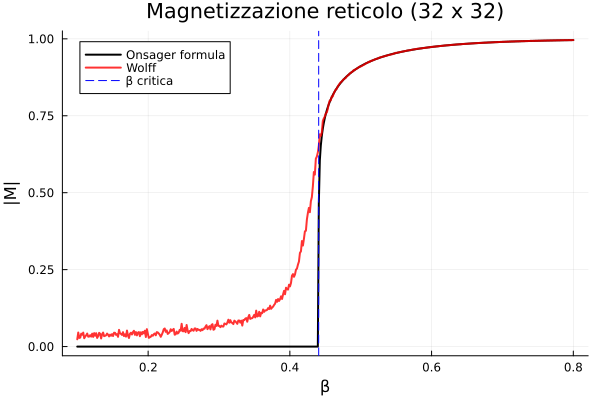

In [5]:
L = 32 
J = clattice(L, L)

betas = range(0.1, 0.8, length=500)
M = Float64[]

n_steps_total = 3000
n_therm = 1000 

for β in betas
    m_avg = magnetization(J, β, n_steps_total, n_therm)
    push!(M, m_avg)
end

#plot
exact_M = M_exact.(betas)

#curva teorica
plot(betas, exact_M, label="Onsager formula", lw=2, color=:black)

#simulazione
plot!(betas, M, label="Wolff", lw=2, color=:red, alpha=0.8)

#beta critico
vline!([β_c], label="β critica", ls=:dash, color=:blue)

title!("Magnetizzazione reticolo ($L x $L)")
xlabel!("β")
ylabel!("|M|")

**PUNTO 2**

In [6]:
includet("punt2.jl")

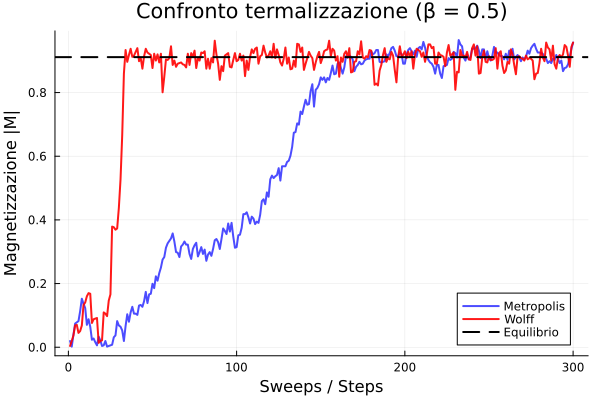

In [8]:
L = 32
N = L * L
J = clattice(L, L)

#beta superiore al punto critico
β_test = 0.5
n_steps = 300

#metropolis

σ_metropolis = rand((-1, 1), N) # Partiamo da uno stato casuale (M circa 0)
#partiamo da configurazioni iniziali identiche
σ_wolff = copy(σ_metropolis)
mag_metropolis = Float64[]

for t in 1:n_steps
    metropolis_sweep!(J, β_test, σ_metropolis)
    push!(mag_metropolis, abs(sum(σ_metropolis)) / N)
end

#Wolff

mag_wolff = Float64[]

my_stats = (t, σ, Q) -> begin
    push!(mag_wolff, abs(sum(σ)) / N)
end


wolffsigma!(J, β_test, σ_wolff, n_steps, stats=my_stats)


M_teorica = M_exact(β_test)

plot(1:n_steps, mag_metropolis, label="Metropolis", lw=2, color=:blue, alpha=0.7)
plot!(1:n_steps, mag_wolff, label="Wolff", lw=2, color=:red, alpha=0.9)
hline!([M_teorica], label="Equilibrio", ls=:dash, color=:black, lw=2)

title!("Confronto termalizzazione (β = $β_test)")
xlabel!("Sweeps / Steps")
ylabel!("Magnetizzazione |M|")

punto 3

In [9]:
includet("punto3.jl")

stima β_c ≈ 0.2215


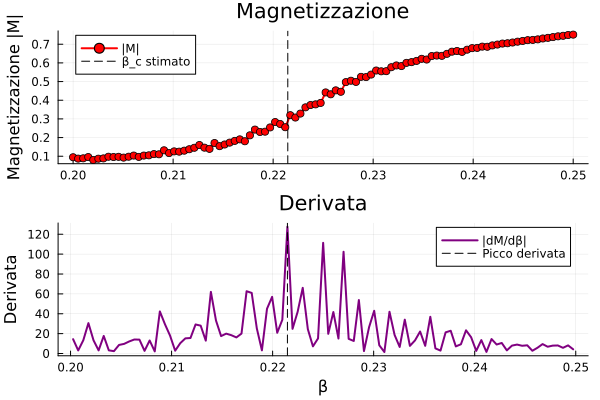

In [15]:
L = 12
J_3D = clattice(L, L, L) 
betas_3d = range(0.20, 0.25, length=100) 

M_3D = Float64[]
chi_3D = Float64[]
n_steps_total = 3000
n_therm = 1000 


for β in betas_3d
    m_avg, chi = magnetization_3d(J_3D, β, n_steps_total, n_therm)
    push!(M_3D, m_avg)
    push!(chi_3D, chi)
end

#stima con derivata della magnetizzazione

derivate = Float64[]
betas = Float64[]


for i in 1:(length(betas_3d) - 1)
    ΔM = M_3D[i+1] - M_3D[i]
    Δβ = betas_3d[i+1] - betas_3d[i]
    
    derivata = abs(ΔM / Δβ) 
    beta_medio = (betas_3d[i+1] + betas_3d[i]) / 2
    
    push!(derivate, derivata)
    push!(betas, beta_medio)
end


peak = argmax(derivate)
beta_c_stimato = betas[peak]

println("stima β_c ≈ $(round(beta_c_stimato, digits=4))")

#Plot
p1 = plot(betas_3d, M_3D, label="|M|", lw=2, color=:red, marker=:circle)
vline!(p1, [beta_c_stimato], label="β_c stimato", ls=:dash, color=:black)
ylabel!(p1, "Magnetizzazione |M|")


p2 = plot(betas, derivate, label="|dM/dβ|", lw=2, color=:purple)
vline!(p2, [beta_c_stimato], label="Picco derivata", ls=:dash, color=:black)
xlabel!(p2, "β")
ylabel!(p2, "Derivata")

plot(p1, p2, layout=(2,1), title=["Magnetizzazione" "Derivata"])

In [16]:
M_3D_12 = copy(M_3D);

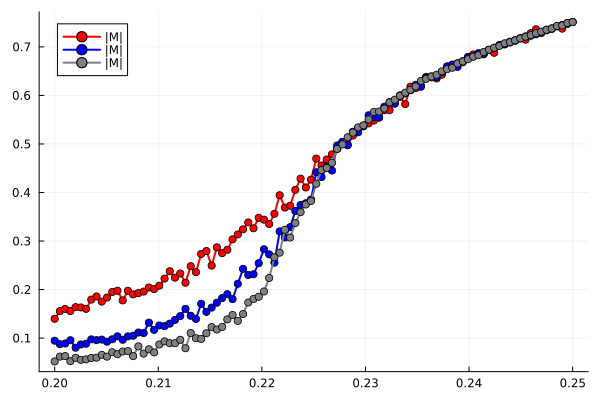

In [18]:
p1 = plot(betas_3d, M_3D_8, label="|M|", lw=2, color=:red, marker=:circle)
p2 = plot!(betas_3d, M_3D_12, label="|M|", lw=2, color=:blue, marker=:circle)
p2 = plot!(betas_3d, M_3D_16, label="|M|", lw=2, color=:grey, marker=:circle)



stima B_c tramite χ: 0.2212


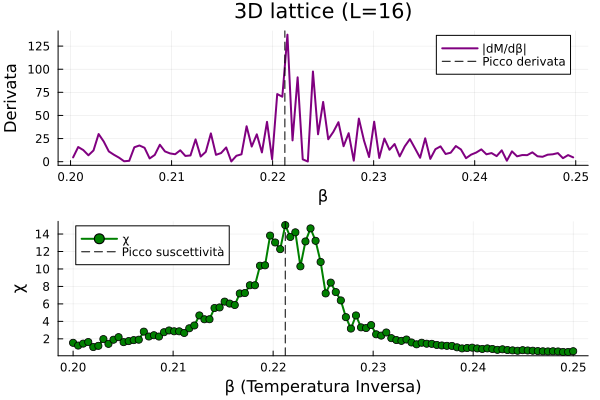

In [15]:
N_spin = L^3

peak = argmax(chi_3D)
beta_c_stimato = betas_3d[peak]

println("stima B_c tramite χ: $(round(beta_c_stimato, digits=4))")

#Suscettività
p3 = plot(betas_3d, chi_3D, label="χ", lw=2, color=:green, marker=:circle, legend=:topleft)
vline!(p3, [beta_c_stimato], label="Picco suscettività", ls=:dash, color=:black)
xlabel!(p3, "β (Temperatura Inversa)")
ylabel!(p3, "χ")

#Derivata
p2 = plot(betas, derivate, label="|dM/dβ|", lw=2, color=:purple)
vline!(p2, [beta_c_stimato], label="Picco derivata", ls=:dash, color=:black)
xlabel!(p2, "β")
ylabel!(p2, "Derivata")


plot(p2, p3, layout=(2,1), title=["3D lattice (L=$L)" ""])

**PUNTO 4**

$$\pi(A) P(A \to B) = \pi(B) P(B \to A)$$

$$H(A) = - \sum_{\langle i,j \rangle} J_{ij} \sigma_i \sigma_j$$

- cluster X $\implies$ nessuno dei legami in $\partial X_{\text{equal sign}}$ viene attivato (lo chiamiamo $\partial X^+$)

$$P(A \to B) = \prod_{(i,j) \in \partial X^+} (1 - p_{ij})$$

- Transizione inversa

$$P(B \to A) = \prod_{(i,j) \in \partial X^-} (1 - p_{ij})$$

$$\frac{\pi(A)}{\pi(B)} = e^{-\beta(H(A) - H(B))}$$

$$H(A) - H(B) = 2 \sum_{\partial X^+} J_{ij} - 2 \sum_{\partial X^-} J_{ij}$$

$$\implies \frac{\pi(A)}{\pi(B)} = e^{-\beta \left( 2 \sum_{\partial X^+} J_{ij} - 2 \sum_{\partial X^-} J_{ij} \right)} =$$

$$= e^{-2\beta \sum_{\partial X^+} J_{ij}} \cdot e^{+2\beta \sum_{\partial X^-} J_{ij}} = \frac{\prod_{\partial X^+} e^{-2\beta J_{ij}}}{\prod_{\partial X^-} e^{-2\beta J_{ij}}}$$

$$\implies \frac{\prod_{(i,j) \in \partial X^+} (1 - p_{ij})}{\prod_{(i,j) \in \partial X^-} (1 - p_{ij})} = \frac{\prod_{(i,j) \in \partial X^+} e^{-2\beta J_{ij}}}{\prod_{(i,j) \in \partial X^-} e^{-2\beta J_{ij}}}$$

$$\implies 1 - p_{ij} = e^{-2\beta J_{ij}} \implies p_{ij} = 1 - e^{-2\beta J_{ij}}$$

In [19]:
includet("punto4.jl")

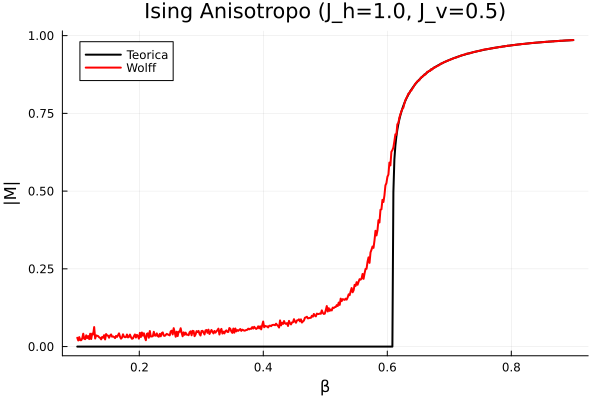

In [20]:
#Modello anisotropo
L = 32

J_h = 1.0 # Forza Orizzontale
J_v = 0.5 # Forza Verticale

# matrici base 
ring_1D = clattice(L)
# J_anis = J_v * Verticale + J_h * Orizzontale
J_anis = kron(I(L), ring_1D * J_v) + kron(ring_1D * J_h, I(L))

#Formula di onsager
function M_exact_anis(β, J_h, J_v)
    if sinh(2 * J_h * β) * sinh(2 * J_v * β) > 1.0
        return (1 - (sinh(2 * J_h * β) * sinh(2 * J_v * β))^(-2))^(1/8)
    else
        return 0.0
    end
end

betas_A = range(0.1, 0.9, length=500)
mag_A = Float64[]


for β in betas_A
    m, chi = heteroising(J_anis, β, 3000, 500)
    push!(mag_A, m)
end

M_teorica = [M_exact_anis(β, J_h, J_v) for β in betas_A]

pA = plot(betas_A, M_teorica, label="Teorica", lw=2, color=:black)
plot!(pA, betas_A, mag_A, label="Wolff",  color=:red, lw=2)
title!(pA, "Ising Anisotropo (J_h=1.0, J_v=0.5)")
xlabel!(pA, "β")
ylabel!(pA, "|M|")



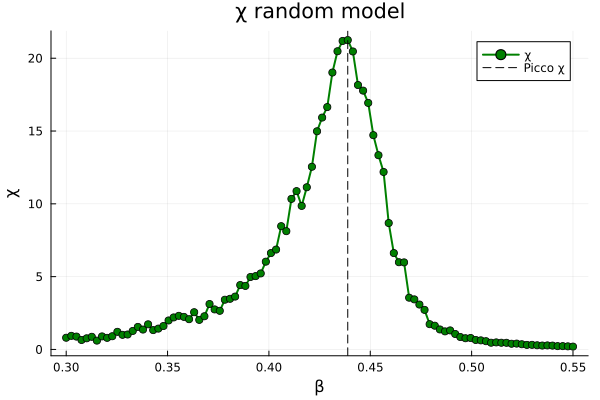

β_c stimato: 0.4389


In [21]:
J_base = clattice(L, L) * 1.0 

#estraggo la matrice triangolare, altrimenti non riesco a farla simmetrica
J_upper = triu(J_base)
for i in 1:length(J_upper.nzval)
    J_upper.nzval[i] = rand() + 0.5 
end
#matrice simmetrica
J_rand = J_upper + transpose(J_upper)


betas_B = range(0.3, 0.55, length=100) 
mag_B = Float64[]
chi_B = Float64[]


for β in betas_B
    m_avg, chi = heteroising(J_rand, β, 3000, 1000)
    push!(mag_B, m_avg)
    push!(chi_B, chi)
end

#stima consuscettività
peak_rand = argmax(chi_B)
beta_c_rand = betas_B[peak_rand]

println("β_c stimato: $(round(beta_c_rand, digits=4))")

pB_chi = plot(betas_B, chi_B, label="χ", lw=2, color=:green, marker=:circle)
vline!(pB_chi, [beta_c_rand], label="Picco χ", ls=:dash, color=:black)
title!(pB_chi, "χ random model")
xlabel!(pB_chi, "β")
ylabel!(pB_chi, "χ")
display(pB_chi)

**PUNTO 5**

a)

$$H(\sigma_1, \dots, \sigma_N) = - \sum_{i < j} J_{ij} \sigma_i \sigma_j - \sum_{i=1}^N h_i \sigma_i$$

$$\tilde{H}(\sigma_1, \dots, \sigma_N, \sigma_{N+1}) = - \sum_{i < j} J_{ij} \sigma_i \sigma_j - \sum_{i=1}^N h_i \sigma_i \sigma_{N+1}$$

$$\tilde{H}(-\sigma_1, \dots, -\sigma_N, -1) = - \sum_{1 \le i < j \le N} J_{ij}(-\sigma_i)(-\sigma_j) - \sum_{i=1}^N h_i(-\sigma_i)(-1) =$$

$$= - \sum_{1 \le i < j \le N} J_{ij} \sigma_i \sigma_j - \sum_{i=1}^N h_i \sigma_i = \tilde{H}(\sigma_1, \dots, \sigma_N, 1)$$

$$\implies \pi_J(-\underline{\sigma}, -1) = \pi_J(\underline{\sigma}, 1)$$


b) 

$$\tilde{Z} = \sum_{\sigma_1, \dots, \sigma_N} \sum_{\sigma_{N+1}} e^{-\beta \tilde{H}(\sigma_1, \dots, \sigma_{N+1})} = \sum_{\sigma_1, \dots, \sigma_N} e^{-\beta \tilde{H}(\sigma_1, \dots, \sigma_N, 1)} +$$

$$+ \sum_{\sigma_1, \dots, \sigma_N} e^{-\beta \tilde{H}(\sigma_1, \dots, \sigma_N, -1)} \underset{(a)}{=} 2 \sum_{\sigma_1, \dots, \sigma_N} e^{-\beta \tilde{H}(\sigma_1, \dots, \sigma_N, 1)} =$$

$$= 2Z$$

$$\implies \pi_J(\sigma_1, \dots, \sigma_N, 1) = \frac{e^{-\beta \tilde{H}(\sigma_1, \dots, \sigma_{N}, 1)}}{\tilde{Z}} =$$

$$= \frac{e^{-\beta H(\sigma_1, \dots, \sigma_N)}}{2Z} = \frac{1}{2} \pi_{J,h}(\sigma_1, \dots, \sigma_N)$$

$$\implies \pi_{J,h}(\sigma_1, \dots, \sigma_N) = 2\pi_J(\sigma_1, \dots, \sigma_N, 1)$$

In [22]:
includet("punto5.jl")

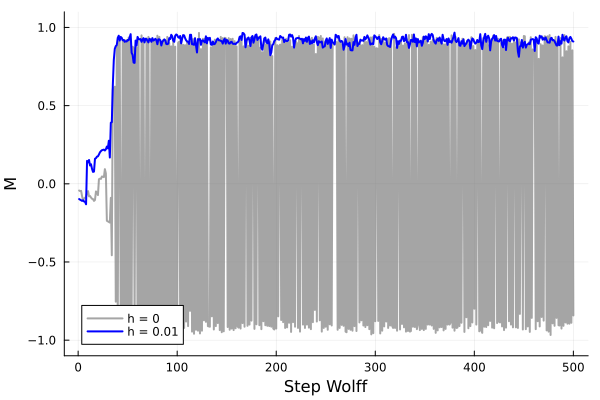

In [23]:
L = 32
J_ferro = 1.0
β_test = 0.5 
steps_storia = 500

#caso h = 0
J_base = clattice(L, L) * J_ferro
storia_h0 = track_mag_zero_field(J_base, β_test, steps_storia)

#caso h = 0.01
h_1 = 0.01
J_field = h_lattice(L, J_ferro, h_1)
storia_h_pos = track_mag_with_field(J_field, β_test, h_1, steps_storia)


#plot
p_storia = plot(1:steps_storia, storia_h0, label="h = 0", color=:gray, alpha=0.7, lw=2)
plot!(p_storia, 1:steps_storia, storia_h_pos, label="h = 0.01", color=:blue, lw=2)


xlabel!(p_storia, "Step Wolff")
ylabel!(p_storia, "M")
ylims!(p_storia, (-1.1, 1.1))
display(p_storia)

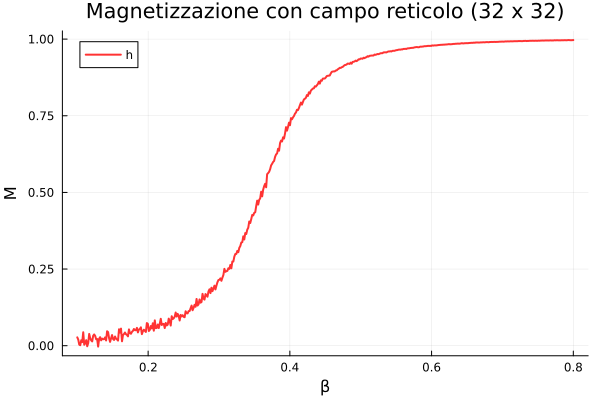

In [25]:
h_1 = 0.1
betas = range(0.1, 0.8, length=500)
M_1 = Float64[]
J_field = h_lattice(L, J_ferro, h_1)

n_steps_total = 1000
n_therm = 500

for β in betas
    m_avg = h_ising(J_field, β, h_1, n_steps_total, n_therm)
    push!(M_1, m_avg)
end


plot(betas, M_1, label="h", lw=2, color=:red, alpha=0.8)


title!("Magnetizzazione con campo reticolo ($L x $L)")
xlabel!("β")
ylabel!("M")

**PUNTO 6**

In [24]:
includet("punto6.jl")

In [25]:
#edward-anderson model

L = 100
N_spin = L * L
J_base = clattice(L, L) * 1.0
J_upper = triu(J_base)
J_upper.nzval .= rand((1.0, -1.0), length(J_upper.nzval))
J_ea = J_upper + transpose(J_upper)


β_target = 1.0
n_steps_total = 2000
n_therm = 500

energiespin = Float64[]

my_stats = (t, σ, Q) -> begin
    if t > n_therm
        push!(energiespin, energy(J_ea, σ) / N_spin) 
    end
end


wolff_spin_glass(J_ea, β_target, n_steps_total, stats=my_stats)

energia_media = mean(energiespin)
println("Energia media per spin: $(round(energia_media, digits=4))")

Energia media per spin: -1.2884


In [26]:
L = 100
N_spin = L * L
β_randomh = 1.0
J_ferro = 1.0 

J_randomh = randomh_lattice(L, J_ferro)


energie_randomh = Float64[]
n_steps_randomh = 2000 
n_therm_randomh = 500  


stats_randomh = (t, σ, Q) -> begin
    if t > n_therm_randomh
        E_tot = energy(J_randomh, σ)
        push!(energie_randomh, E_tot / N_spin)
    end
end

wolff_spin_glass(J_randomh, β_randomh, n_steps_randomh, stats=stats_randomh)

energia_media_randomh = mean(energie_randomh)
println("Energia media per spin: $(round(energia_media_randomh, digits=4))")

Energia media per spin: -1.8176
